# Домашнее задание #3: исследование KNN

Выполнил: *[впиши своё имя]*

## Цель работы
Исследовать работу алгоритма **k ближайших соседей (KNN)** на реальном датасете:
- выбрать датасет;
- провести первичный анализ данных;
- подготовить признаки;
- обучить KNN;
- исследовать влияние параметра `k`;
- подобрать лучшие гиперпараметры;
- сделать выводы.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 1. Выберите датасет

Я выбрал датасет **Wine** из `sklearn.datasets`.

### Почему этот датасет подходит
- это задача **классификации**;
- в датасете несколько числовых признаков;
- классов больше двух, значит задача чуть интереснее;
- для KNN он хорошо подходит, потому что можно исследовать влияние масштабирования признаков.

### Кратко о датасете
Датасет содержит характеристики вина и номер класса вина.  
Нужно по признакам определить, к какому из 3 классов относится объект.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Названия признаков:")
print(X.columns.tolist())
print("\nНазвания классов:")
print(wine.target_names)

Размер X: (178, 13)
Размер y: (178,)
Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Названия классов:
['class_0' 'class_1' 'class_2']


In [3]:
display(X.head())
display(y.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

## 2. Первичный анализ данных

Сначала посмотрим:
- есть ли пропуски;
- какие типы данных;
- как распределены классы;
- какие диапазоны значений у признаков.

Это важно, потому что KNN основан на расстояниях между объектами.  
Если признаки имеют сильно разные масштабы, то большие по величине признаки могут слишком сильно влиять на результат.

In [4]:
print("Информация о таблице:")
X.info()

Информация о таблице:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64

In [5]:
print("Пропуски по столбцам:")
display(X.isnull().sum())

print("Количество объектов каждого класса:")
display(y.value_counts().sort_index())

Пропуски по столбцам:


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Количество объектов каждого класса:


target
0    59
1    71
2    48
Name: count, dtype: int64

In [6]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


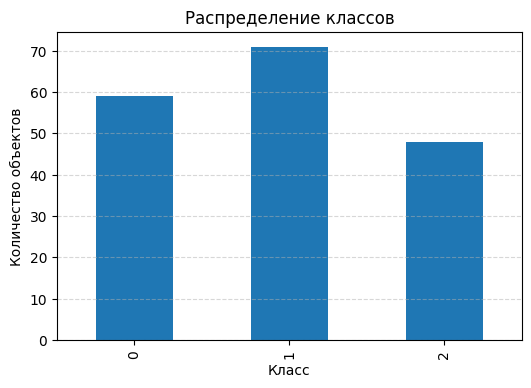

In [7]:
plt.figure(figsize=(6, 4))
y.value_counts().sort_index().plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Вывод по первичному анализу

По результатам анализа видно:
- пропусков в датасете нет;
- все признаки числовые;
- классы распределены достаточно нормально, сильного дисбаланса нет;
- признаки имеют разные масштабы.

Последний пункт особенно важен для KNN, поэтому далее обязательно проверим качество:
1. без масштабирования;
2. со стандартизацией.

## 3. Подготовка данных

Разделим выборку на обучающую и тестовую части.

Используем `train_test_split`, чтобы честно оценить качество модели на данных, которые она не видела во время обучения.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (133, 13)
X_test: (45, 13)
y_train: (133,)
y_test: (45,)


## 4. Первая модель KNN без масштабирования

Сначала обучим KNN на исходных данных без стандартизации.  
Это нужно, чтобы потом сравнить результат с вариантом, где признаки приведены к одному масштабу.

In [9]:
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)

y_pred_raw = knn_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)
print("Accuracy без масштабирования:", acc_raw)

Accuracy без масштабирования: 0.7777777777777778


In [10]:
print("Classification report (без масштабирования):")
print(classification_report(y_test, y_pred_raw))

Classification report (без масштабирования):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.75      0.67      0.71        18
           2       0.57      0.67      0.62        12

    accuracy                           0.78        45
   macro avg       0.77      0.78      0.77        45
weighted avg       0.79      0.78      0.78        45



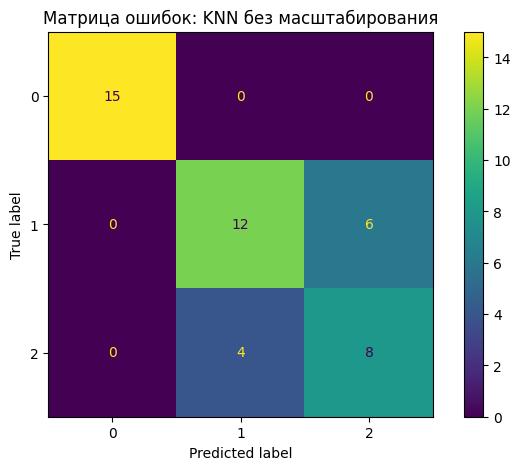

In [12]:
cm_raw = confusion_matrix(y_test, y_pred_raw)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_raw)
disp.plot()
plt.title("Матрица ошибок: KNN без масштабирования")
plt.show()

## 5. KNN со стандартизацией

Теперь применим `StandardScaler`.

Стандартизация делает так, что у признаков:
- среднее становится около 0;
- стандартное отклонение становится около 1.

Для KNN это обычно очень полезно, потому что расстояния между объектами начинают считаться более корректно.

In [13]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipe.fit(X_train, y_train)
y_pred_scaled = pipe.predict(X_test)

acc_scaled = accuracy_score(y_test, y_pred_scaled)
print("Accuracy со стандартизацией:", acc_scaled)

Accuracy со стандартизацией: 0.9333333333333333


In [14]:
print("Classification report (со стандартизацией):")
print(classification_report(y_test, y_pred_scaled))

Classification report (со стандартизацией):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      0.89      0.91        18
           2       0.85      0.92      0.88        12

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



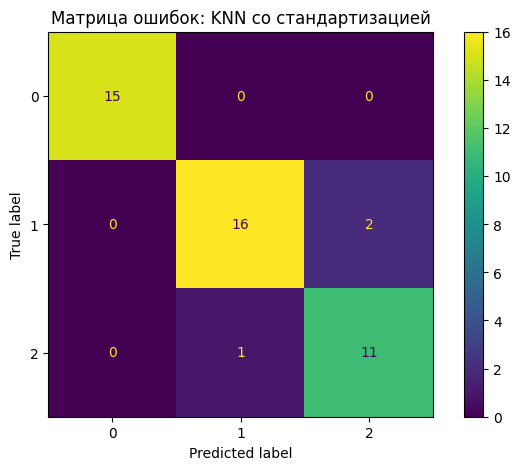

In [15]:
cm_scaled = confusion_matrix(y_test, y_pred_scaled)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_scaled)
disp.plot()
plt.title("Матрица ошибок: KNN со стандартизацией")
plt.show()

### Сравнение двух подходов

Сравним качество модели:
- без масштабирования;
- со стандартизацией.

In [16]:
comparison = pd.DataFrame({
    "Модель": ["KNN без масштабирования", "KNN со стандартизацией"],
    "Accuracy": [acc_raw, acc_scaled]
})

display(comparison)

,Модель,Accuracy
0,KNN без масштабирования,0.777778
1,KNN со стандартизацией,0.933333


### Вывод

Обычно KNN показывает более качественный результат после стандартизации, потому что алгоритм основан на расстояниях.  
Если один признак измеряется в больших числах, а другой — в маленьких, то без масштабирования модель может работать хуже.

Поэтому для KNN стандартизация признаков чаще всего является важным этапом подготовки данных.

## 6. Исследование влияния параметра k

Теперь посмотрим, как меняется качество модели при разных значениях `k`.

Параметр `k` — это количество ближайших соседей, по которым принимается решение о классе объекта.

In [17]:
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

In [18]:
results_k = pd.DataFrame({
    "k": list(k_values),
    "train_accuracy": train_scores,
    "test_accuracy": test_scores
})

display(results_k.head(10))

,k,train_accuracy,test_accuracy
0,1,1.000000,0.955556
1,2,0.969925,0.933333
2,3,0.977444,0.955556
3,4,0.977444,0.933333
4,5,0.992481,0.933333
5,6,0.977444,0.933333
6,7,0.969925,0.977778
7,8,0.969925,0.955556
8,9,0.969925,0.977778
9,10,0.969925,0.977778


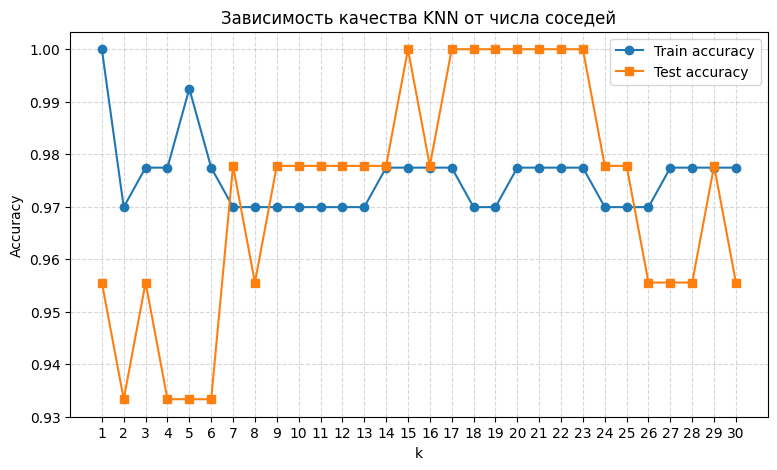

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, train_scores, marker="o", label="Train accuracy")
plt.plot(k_values, test_scores, marker="s", label="Test accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость качества KNN от числа соседей")
plt.xticks(list(k_values))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

### Интерпретация графика

Обычно при очень маленьком `k` модель может переобучаться:
- на обучении качество почти идеальное;
- на тесте хуже.

При слишком большом `k` модель становится слишком грубой:
- решение принимается по слишком большому числу соседей;
- модель может недообучаться.

Нужно выбрать такой `k`, при котором качество на тестовой выборке максимально или близко к максимуму.

## 7. Подбор лучших параметров с помощью GridSearchCV

Теперь подберём параметры автоматически.

Будем искать лучшие значения:
- `n_neighbors`
- `weights`
- `metric`

Такой подход более надёжен, чем выбор параметров вручную.

In [21]:
param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

grid = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [1, 2, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [22]:
print("Лучшие параметры:")
print(grid.best_params_)

print("\nЛучшее среднее качество по кросс-валидации:")
print(grid.best_score_)

Лучшие параметры:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 6, 'knn__weights': 'uniform'}

Лучшее среднее качество по кросс-валидации:
0.9923076923076923


In [23]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

best_test_acc = accuracy_score(y_test, y_pred_best)
print("Accuracy лучшей модели на тестовой выборке:", best_test_acc)

Accuracy лучшей модели на тестовой выборке: 0.9777777777777777


In [24]:
print("Classification report для лучшей модели:")
print(classification_report(y_test, y_pred_best))

Classification report для лучшей модели:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## 8. Бонус: визуализация через PCA

Так как признаков много, напрямую изобразить данные трудно.  
Поэтому уменьшим размерность до 2 компонент с помощью PCA и посмотрим, как примерно располагаются объекты разных классов.

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = y.values

display(pca_df.head())

,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


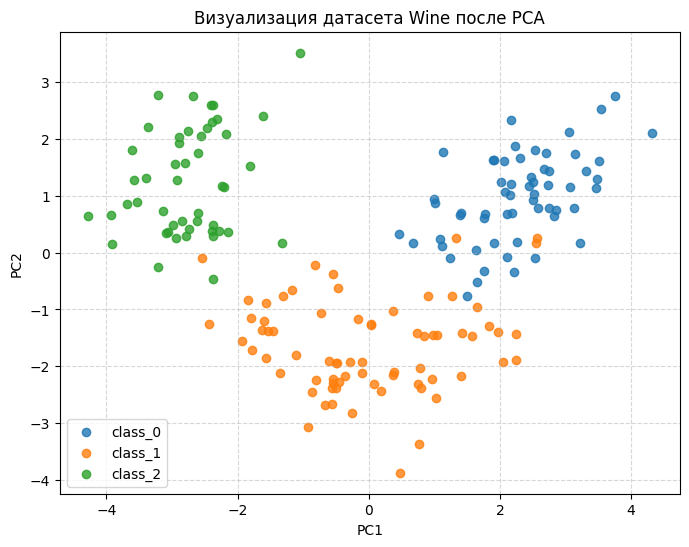

In [26]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(wine.target_names):
    mask = pca_df["target"] == class_id
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        label=class_name,
        alpha=0.8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Визуализация датасета Wine после PCA")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 9. Итоговые выводы

В ходе работы был исследован алгоритм **k ближайших соседей (KNN)** на датасете **Wine**.

### Что было сделано
1. Выбран датасет классификации `Wine`.
2. Проведён первичный анализ данных.
3. Проверено отсутствие пропусков.
4. Выполнено разделение на обучающую и тестовую выборки.
5. Обучен KNN без масштабирования.
6. Обучен KNN со стандартизацией.
7. Исследовано влияние параметра `k`.
8. Подобраны лучшие гиперпараметры через `GridSearchCV`.
9. Построена дополнительная PCA-визуализация.

### Основные выводы
- KNN чувствителен к масштабу признаков.
- Стандартизация обычно улучшает качество модели.
- Слишком маленькое `k` может приводить к переобучению.
- Слишком большое `k` может ухудшать качество из-за чрезмерного усреднения.
- Подбор гиперпараметров помогает найти более удачную конфигурацию модели.

### Общий вывод
Алгоритм KNN прост в понимании и применении, но требует:
- аккуратной подготовки данных;
- нормализации или стандартизации признаков;
- подбора числа соседей.